# E-Commerce Customer Churn — Explainable ML Pipeline

**Focus:** Every model and every explanation must be interpretable by a business stakeholder.

## Model selection rationale

| Model | Native explainability | SHAP support |
|---|---|---|
| **Logistic Regression** | Coefficients = direct log-odds per feature | ✅ LinearExplainer (fast, exact) |
| **Random Forest** | Mean Decrease in Impurity across trees | ✅ TreeExplainer (fast, exact) |
| **XGBoost** | Gain-based feature importance | ✅ TreeExplainer (fast, exact) |

**Dropped:** Naïve Bayes (independence assumption makes parameters misleading on correlated features),
SVM with RBF kernel (kernel trick → no readable weight vector; KernelSHAP works but is very slow),
TabPFN (transformer — black box), Soft-Voting Ensemble (averaging probabilities destroys per-model interpretability).

**Explainability stack:** native importances + SHAP only. No LIME.

## Sections
1. Imports & Configuration
2. Data Loading & Feature Engineering
3. Exploratory Data Analysis
4. Train / Test Split & SMOTE
5. Shared Evaluation Helper
6. Logistic Regression — Coefficients & Odds Ratios + SHAP
7. Random Forest — MDI Importance + SHAP
8. XGBoost — Gain Importance + SHAP
9. Cross-Model SHAP Comparison
10. Individual Prediction Explainer (Waterfall & Force plots)
11. Results Summary


## 1 · Imports & Configuration

In [31]:
# pip install imbalanced-learn xgboost shap==0.51.0
# Note: shap>=0.51.0 is required for XGBoost 3.x compatibility
import warnings, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay,
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
SEED = 42
np.random.seed(SEED)

print("All imports OK")
print(f"SHAP version: {shap.__version__}")


All imports OK
SHAP version: 0.51.0


## 2 · Data Loading & Feature Engineering
Raw data is transaction-level. We aggregate to one row per **customer** and
engineer behavioural features before modelling.


In [32]:
df = pd.read_csv("E Commerce Customer Insights and Churn Dataset.csv")

# ── Date parsing ────────────────────────────────────────────────────────────────
for col in ["signup_date", "last_purchase_date", "order_date"]:
    df[col] = pd.to_datetime(df[col])

# ── Cleaning ────────────────────────────────────────────────────────────────────
df = df.drop_duplicates()
for col in ["country", "gender", "subscription_status", "preferred_category"]:
    df[col] = df[col].str.strip().str.lower()

# ── Transaction-level features ──────────────────────────────────────────────────
reference_date = df["last_purchase_date"].max()
df["customer_tenure_days"]     = (reference_date - df["signup_date"]).dt.days
df["days_since_last_purchase"] = (reference_date - df["last_purchase_date"]).dt.days

# ── Aggregate to customer level ─────────────────────────────────────────────────
customer_df = df.groupby("customer_id").agg(
    customer_tenure_days     = ("customer_tenure_days",     "max"),
    days_since_last_purchase = ("days_since_last_purchase", "min"),
    quantity                 = ("quantity",                 "sum"),
    unit_price               = ("unit_price",               "mean"),
    cancellations_count      = ("cancellations_count",      "sum"),
    purchase_frequency       = ("purchase_frequency",       "mean"),
    subscription_status      = ("subscription_status",      "last"),
    country                  = ("country",                  "last"),
    gender                   = ("gender",                   "last"),
    preferred_category       = ("preferred_category",       "last"),
    age                      = ("age",                      "mean"),
).reset_index()

customer_df["total_spent"] = (
    df.groupby("customer_id")
      .apply(lambda x: (x["quantity"] * x["unit_price"]).sum())
      .values
)

# ── Target variable ─────────────────────────────────────────────────────────────
customer_df["churn"] = (customer_df["subscription_status"] == "cancelled").astype(int)
customer_df = customer_df.drop(columns=["customer_id", "subscription_status"])

# ── One-hot encoding (drop_first avoids multicollinearity) ──────────────────────
customer_df = pd.get_dummies(
    customer_df,
    columns=["country", "gender", "preferred_category"],
    drop_first=True,
)

print(f"Dataset shape : {customer_df.shape}")
print(f"Churn rate    : {customer_df['churn'].mean():.1%}")
print(f"Features      : {customer_df.shape[1] - 1}")
print(f"\nColumns:\n{list(customer_df.columns)}")


Dataset shape : (2000, 20)
Churn rate    : 24.6%
Features      : 19

Columns:
['customer_tenure_days', 'days_since_last_purchase', 'quantity', 'unit_price', 'cancellations_count', 'purchase_frequency', 'age', 'total_spent', 'churn', 'country_germany', 'country_india', 'country_pakistan', 'country_uk', 'country_usa', 'gender_male', 'gender_other', 'preferred_category_clothing', 'preferred_category_electronics', 'preferred_category_home', 'preferred_category_sports']


## 3 · Exploratory Data Analysis

### 3.1 Basic statistics

In [33]:
print("=== Missing values ===")
missing = customer_df.isnull().sum()
print(missing[missing > 0] if missing.any() else "None")

num_cols = ["customer_tenure_days", "days_since_last_purchase", "quantity",
            "unit_price", "cancellations_count", "purchase_frequency",
            "age", "total_spent"]
customer_df[num_cols].describe().round(2)


=== Missing values ===
None


,customer_tenure_days,days_since_last_purchase,quantity,unit_price,cancellations_count,purchase_frequency,age,total_spent
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,1285.95,630.22,4.95,324.72,2.44,25.16,44.08,1025.85
std,313.31,410.96,2.56,361.55,1.70,14.16,14.80,560.79
min,731.00,0.00,1.00,2.85,0.00,1.00,18.00,22.29
25%,1016.00,284.00,3.00,111.13,1.00,13.00,31.00,551.94
50%,1299.00,585.00,5.00,206.52,2.00,25.00,45.00,1057.23
75%,1557.25,906.00,7.00,384.51,4.00,37.00,57.00,1494.68
max,1826.00,1795.00,9.00,1991.63,5.00,49.00,69.00,1998.08


### 3.2 Churn distribution

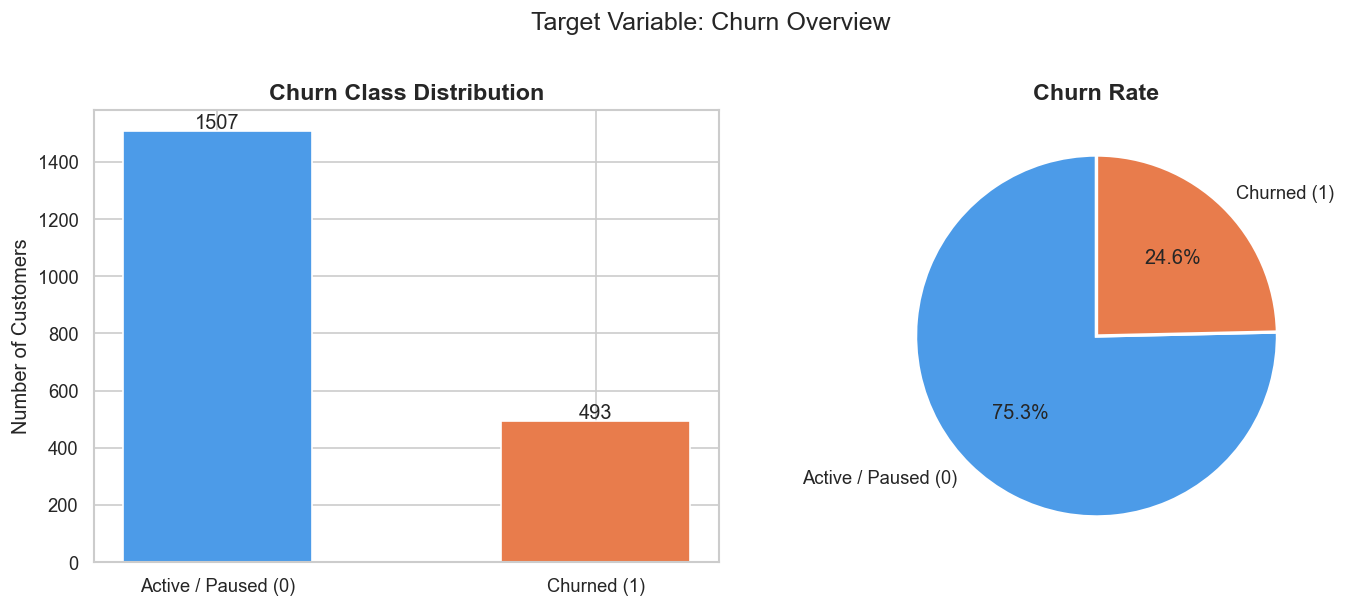

Overall churn rate: 24.6%


In [34]:
churn_counts = customer_df["churn"].value_counts()
labels = ["Active / Paused (0)", "Churned (1)"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(labels, churn_counts.values,
            color=["#4C9BE8", "#E87C4C"], edgecolor="white", width=0.5)
axes[0].set_title("Churn Class Distribution", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Number of Customers")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontsize=12)

axes[1].pie(churn_counts.values, labels=labels, autopct="%1.1f%%",
            colors=["#4C9BE8", "#E87C4C"], startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Churn Rate", fontsize=14, fontweight="bold")

plt.suptitle("Target Variable: Churn Overview", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("chart1_churn_distribution.png", bbox_inches="tight")
plt.show()
print(f"Overall churn rate: {customer_df['churn'].mean():.1%}")


### 3.3 Churn rate by country & preferred category

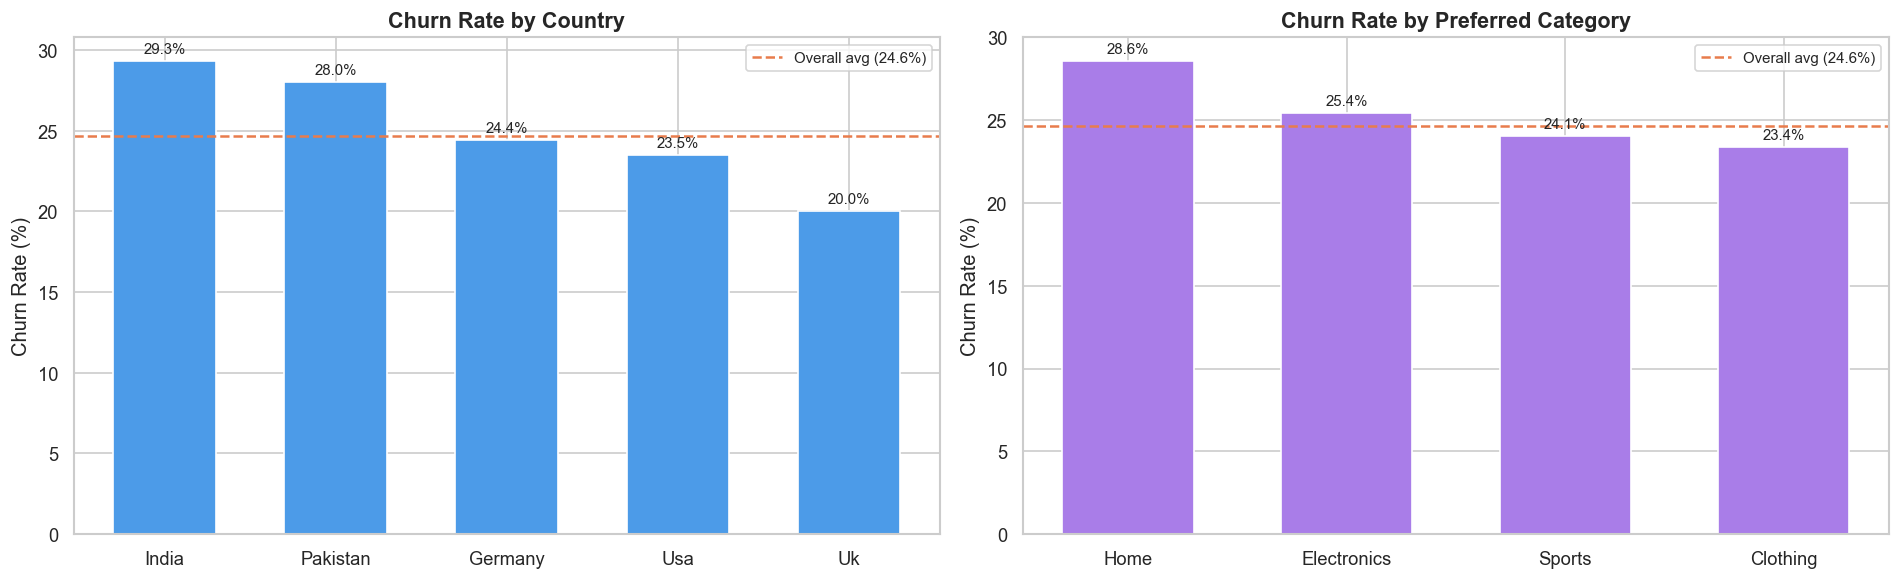

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, prefix, title, color in [
    (axes[0], "country_",            "Churn Rate by Country",            "#4C9BE8"),
    (axes[1], "preferred_category_", "Churn Rate by Preferred Category", "#A97DE8"),
]:
    cols = [c for c in customer_df.columns if c.startswith(prefix)]
    series = pd.Series(
        {c.replace(prefix, "").title():
         customer_df[customer_df[c] == 1]["churn"].mean()
         for c in cols}
    ).sort_values(ascending=False)
    bars = ax.bar(series.index, series.values * 100, color=color,
                  edgecolor="white", width=0.6)
    ax.axhline(customer_df["churn"].mean() * 100, color="#E87C4C",
               linestyle="--", linewidth=1.5,
               label=f"Overall avg ({customer_df['churn'].mean():.1%})")
    ax.set_ylabel("Churn Rate (%)")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(fontsize=9)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3,
                f"{h:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("chart2_churn_by_segment.png", bbox_inches="tight")
plt.show()


### 3.4 Feature distributions — churned vs. retained

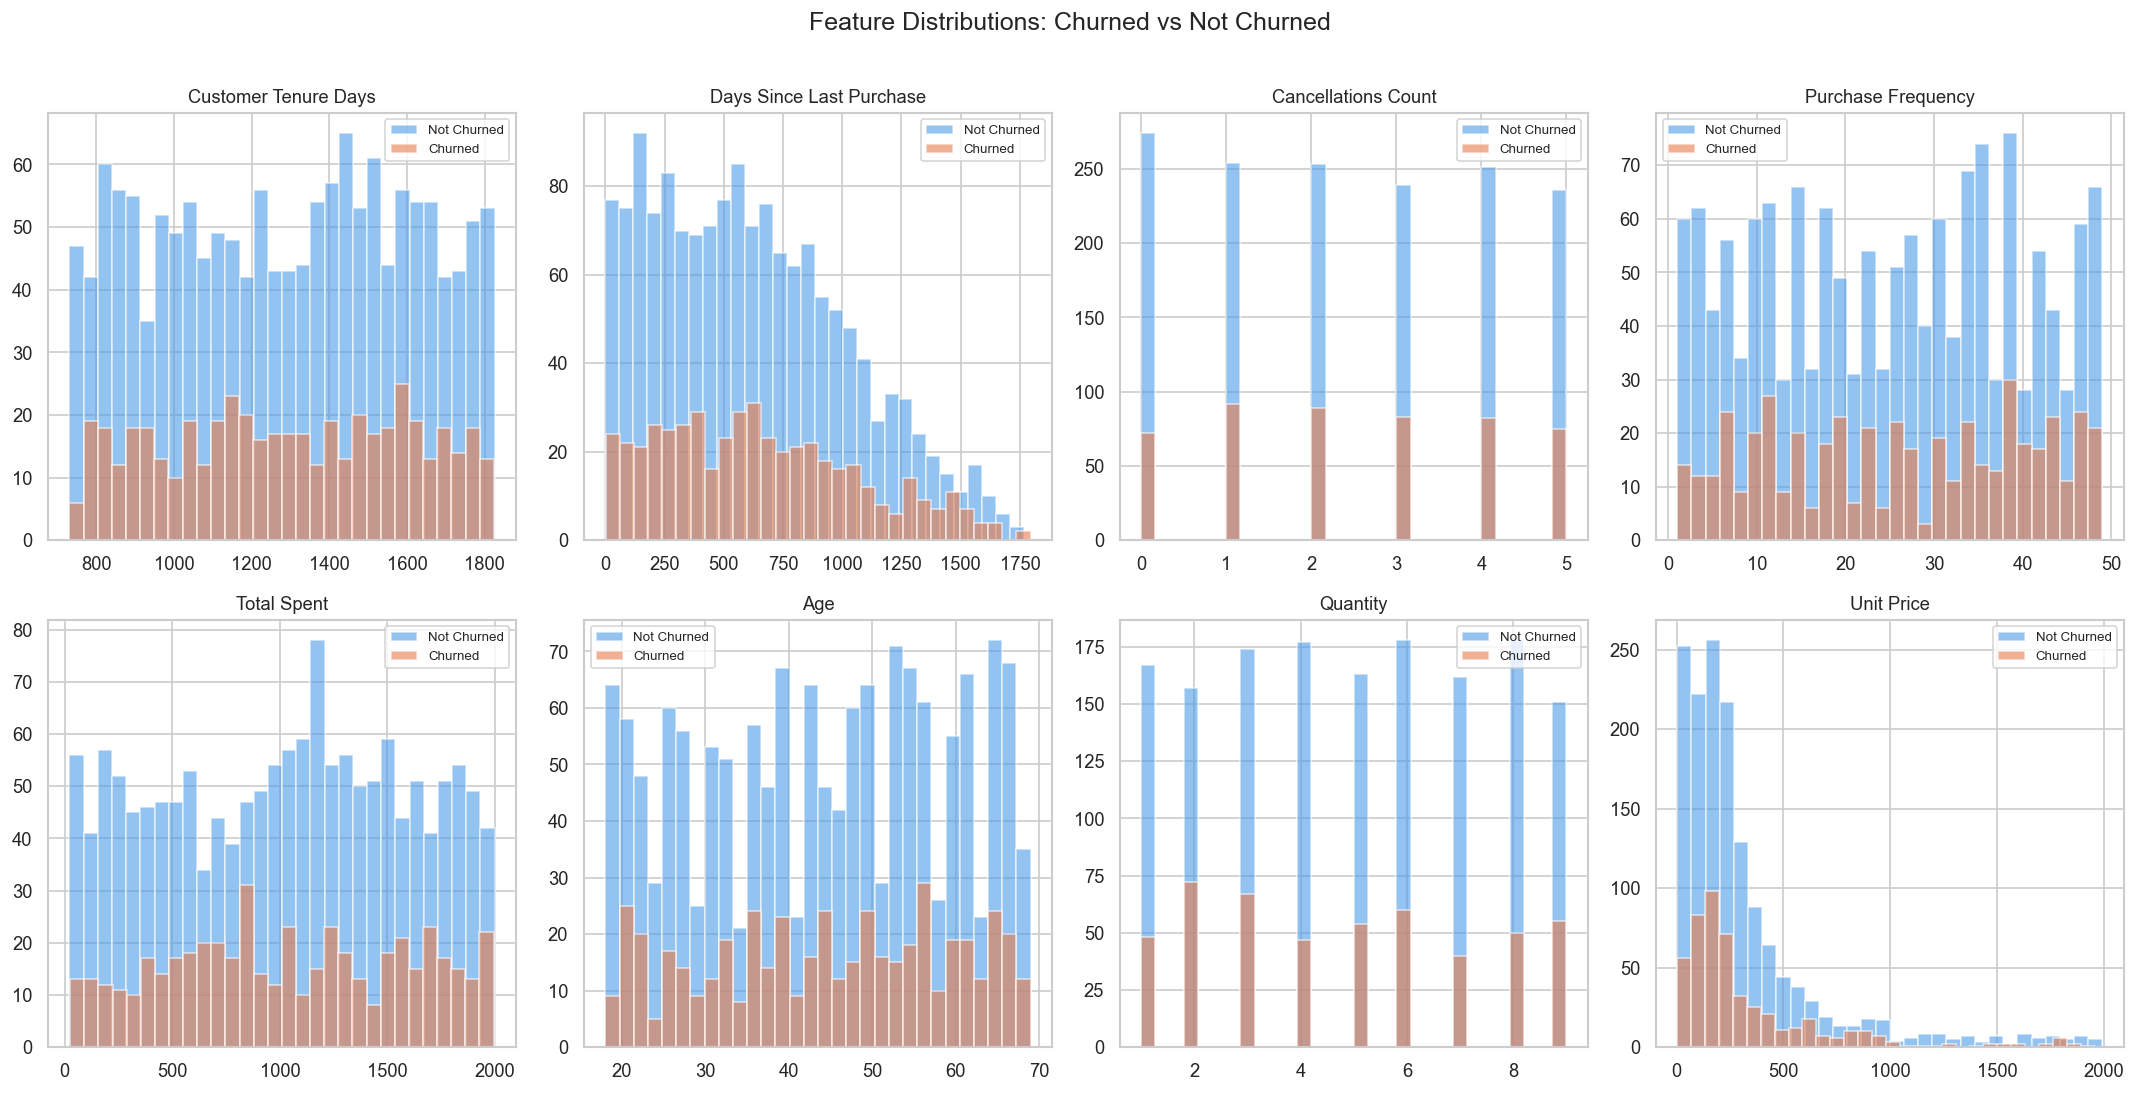

In [36]:
num_features = ["customer_tenure_days", "days_since_last_purchase",
                "cancellations_count", "purchase_frequency",
                "total_spent", "age", "quantity", "unit_price"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    churned     = customer_df[customer_df["churn"] == 1][feat]
    not_churned = customer_df[customer_df["churn"] == 0][feat]
    axes[i].hist(not_churned, bins=30, alpha=0.6, color="#4C9BE8", label="Not Churned")
    axes[i].hist(churned,     bins=30, alpha=0.6, color="#E87C4C", label="Churned")
    axes[i].set_title(feat.replace("_", " ").title(), fontsize=11)
    axes[i].legend(fontsize=8)

plt.suptitle("Feature Distributions: Churned vs Not Churned", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("chart3_feature_distributions.png", bbox_inches="tight")
plt.show()


### 3.5 Correlation heatmap

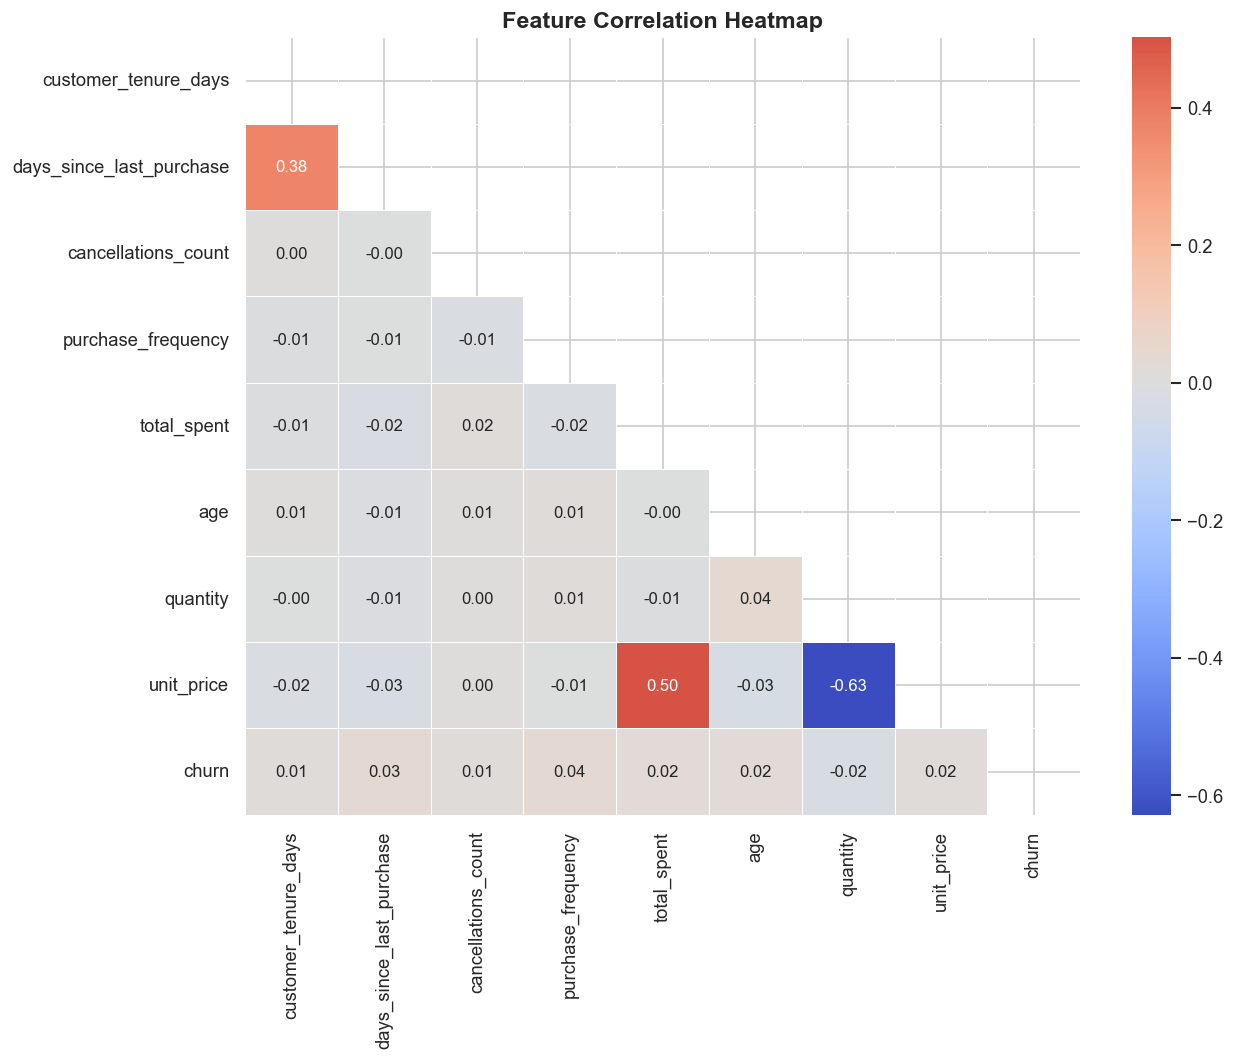


Top correlations with churn:
country_uk                 -0.0497
country_india               0.0477
preferred_category_home     0.0454
purchase_frequency          0.0366
country_pakistan            0.0348
days_since_last_purchase    0.0345
quantity                   -0.0243
gender_male                -0.0234
total_spent                 0.0214
age                         0.0210


In [37]:
corr_cols = num_features + ["churn"]
corr = customer_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 10})
ax.set_title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("chart4_correlation_heatmap.png", bbox_inches="tight")
plt.show()

print("\nTop correlations with churn:")
print(customer_df.corr(numeric_only=True)["churn"]
      .drop("churn").sort_values(key=abs, ascending=False)
      .round(4).head(10).to_string())


## 4 · Train / Test Split & SMOTE
SMOTE is applied **only on the training fold** to avoid leakage.
Tree models receive **raw (unscaled)** features; Logistic Regression
receives **standardised** features.


In [38]:
X = customer_df.drop("churn", axis=1)
y = customer_df["churn"]
feature_names = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Class balance before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=SEED)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nClass balance after SMOTE:")
print(pd.Series(y_train_res).value_counts())

# Scaled — Logistic Regression needs standardised features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)
X_test_sc  = scaler.transform(X_test)

# Raw — tree models are invariant to monotone feature transformations
X_train_raw = np.array(X_train_res)
X_test_raw  = np.array(X_test)

print(f"\nTrain: {X_train_sc.shape[0]} rows  |  Test: {X_test_sc.shape[0]} rows")


Class balance before SMOTE:
churn
0    1206
1     394
Name: count, dtype: int64

Class balance after SMOTE:
churn
1    1206
0    1206
Name: count, dtype: int64

Train: 2412 rows  |  Test: 400 rows


## 5 · Shared Evaluation Helper

In [39]:
results = {}  # accumulates metrics, predictions, and fitted models

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - t0

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    metrics = dict(
        Accuracy  = accuracy_score(y_te, y_pred),
        Precision = precision_score(y_te, y_pred, zero_division=0),
        Recall    = recall_score(y_te, y_pred, zero_division=0),
        F1        = f1_score(y_te, y_pred, zero_division=0),
        ROC_AUC   = roc_auc_score(y_te, y_prob),
        Train_sec = round(elapsed, 2),
    )
    results[name] = {
        "model": model, "metrics": metrics,
        "y_pred": y_pred, "y_prob": y_prob,
    }

    print(f"{'='*50}")
    print(f"  {name}  ({elapsed:.2f}s)")
    print(f"  Accuracy   : {metrics['Accuracy']:.4f}")
    print(f"  Precision  : {metrics['Precision']:.4f}")
    print(f"  Recall     : {metrics['Recall']:.4f}")
    print(f"  F1         : {metrics['F1']:.4f}")
    print(f"  ROC-AUC    : {metrics['ROC_AUC']:.4f}")
    print(classification_report(y_te, y_pred,
          target_names=["Not Churned", "Churned"], zero_division=0))
    return model

print("Helper ready.")


Helper ready.


## 6 · Logistic Regression — Coefficients & Odds Ratios + SHAP

### Why it is explainable
Each coefficient $\beta_j$ is the change in **log-odds of churn** for a one-unit
increase in feature $j$, holding all others constant. Exponentiating yields an
**odds ratio** — directly communicable to stakeholders:

> *"A one-unit increase in `cancellations_count` multiplies the odds of churn by X."*

SHAP LinearExplainer gives the exact per-prediction decomposition analytically
(no sampling approximation needed for linear models).


In [40]:
# Note: no class_weight here — SMOTE already perfectly balanced the training set.
# Adding class_weight on top of SMOTE double-penalises the majority class,
# which inflates recall at the cost of precision and overall accuracy.
lr = LogisticRegression(
    C=1.0, solver="lbfgs", max_iter=1000,
    random_state=SEED,
)
evaluate("Logistic Regression", lr, X_train_sc, y_train_res, X_test_sc, y_test)


  Logistic Regression  (0.01s)
  Accuracy   : 0.6575
  Precision  : 0.3021
  Recall     : 0.2929
  F1         : 0.2974
  ROC-AUC    : 0.5310
              precision    recall  f1-score   support

 Not Churned       0.77      0.78      0.77       301
     Churned       0.30      0.29      0.30        99

    accuracy                           0.66       400
   macro avg       0.54      0.54      0.54       400
weighted avg       0.65      0.66      0.66       400



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### 6.1 Coefficient plot (log-odds)

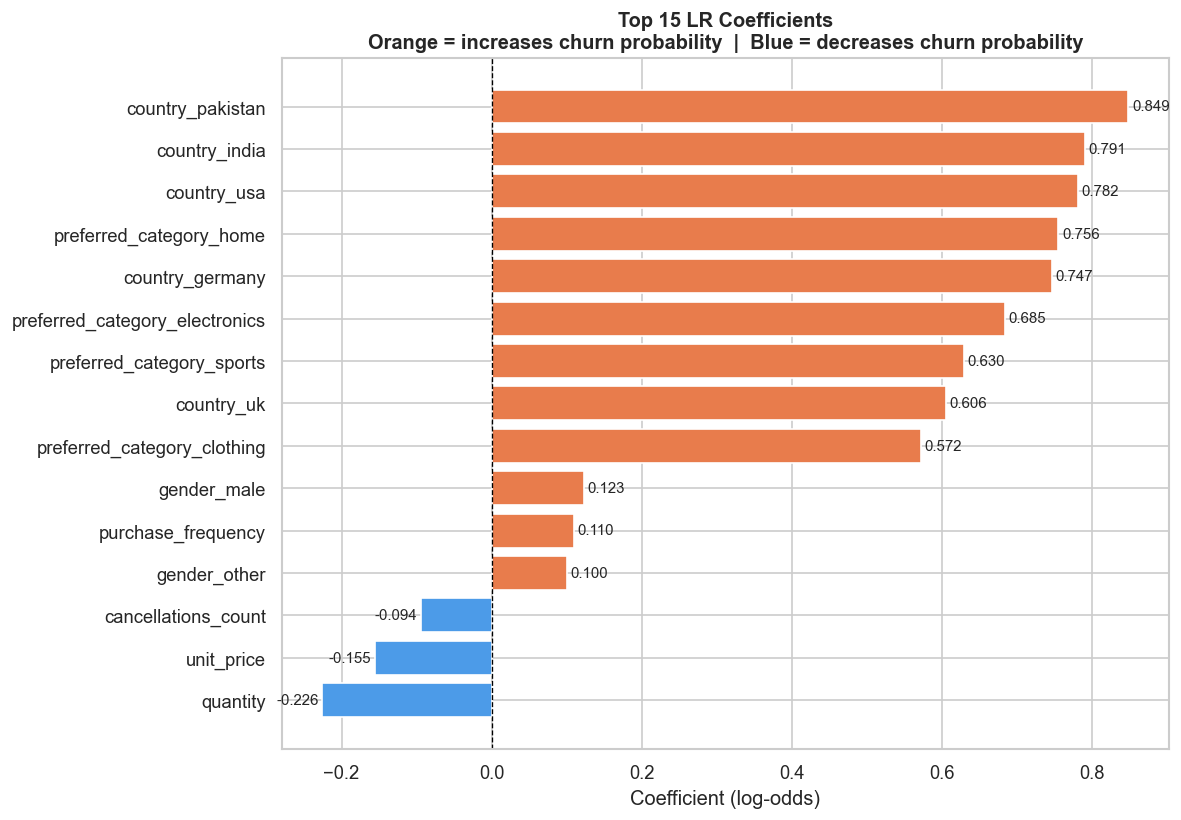

In [41]:
coef_df = (
    pd.DataFrame({"Feature": feature_names, "Coefficient": lr.coef_[0]})
    .sort_values("Coefficient", key=abs, ascending=False)
    .head(15)
    .sort_values("Coefficient")
)
colors_bar = ["#E87C4C" if c > 0 else "#4C9BE8" for c in coef_df["Coefficient"]]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(coef_df["Feature"], coef_df["Coefficient"],
               color=colors_bar, edgecolor="white")
ax.axvline(0, color="black", lw=0.8, linestyle="--")
ax.set_xlabel("Coefficient (log-odds)", fontsize=12)
ax.set_title(
    "Top 15 LR Coefficients\n"
    "Orange = increases churn probability  |  Blue = decreases churn probability",
    fontsize=12, fontweight="bold",
)
for bar, val in zip(bars, coef_df["Coefficient"]):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center",
            ha="left" if val >= 0 else "right", fontsize=9)
plt.tight_layout()
plt.savefig("chart5_lr_coefficients.png", bbox_inches="tight")
plt.show()


### 6.2 Odds ratios — business-friendly view

In [42]:
odds_df = (
    pd.DataFrame({"Feature": feature_names, "Coefficient": lr.coef_[0]})
    .assign(OddsRatio=lambda d: np.exp(d["Coefficient"]))
    .sort_values("OddsRatio", ascending=False)
    .reset_index(drop=True)
)

print("Top 10 features that INCREASE churn odds (OddsRatio > 1):")
print(odds_df.head(10)[["Feature", "Coefficient", "OddsRatio"]].round(4).to_string(index=False))

print("\nTop 10 features that DECREASE churn odds (OddsRatio < 1):")
print(odds_df.tail(10)[["Feature", "Coefficient", "OddsRatio"]]
      .sort_values("OddsRatio").round(4).to_string(index=False))


Top 10 features that INCREASE churn odds (OddsRatio > 1):
                       Feature  Coefficient  OddsRatio
              country_pakistan       0.8493     2.3381
                 country_india       0.7912     2.2061
                   country_usa       0.7816     2.1850
       preferred_category_home       0.7558     2.1293
               country_germany       0.7470     2.1108
preferred_category_electronics       0.6847     1.9832
     preferred_category_sports       0.6301     1.8778
                    country_uk       0.6059     1.8329
   preferred_category_clothing       0.5725     1.7727
                   gender_male       0.1234     1.1313

Top 10 features that DECREASE churn odds (OddsRatio < 1):
                 Feature  Coefficient  OddsRatio
                quantity      -0.2257     0.7980
              unit_price      -0.1552     0.8563
     cancellations_count      -0.0940     0.9103
    customer_tenure_days       0.0254     1.0257
                     age       0.

### 6.3 LR — SHAP (LinearExplainer)

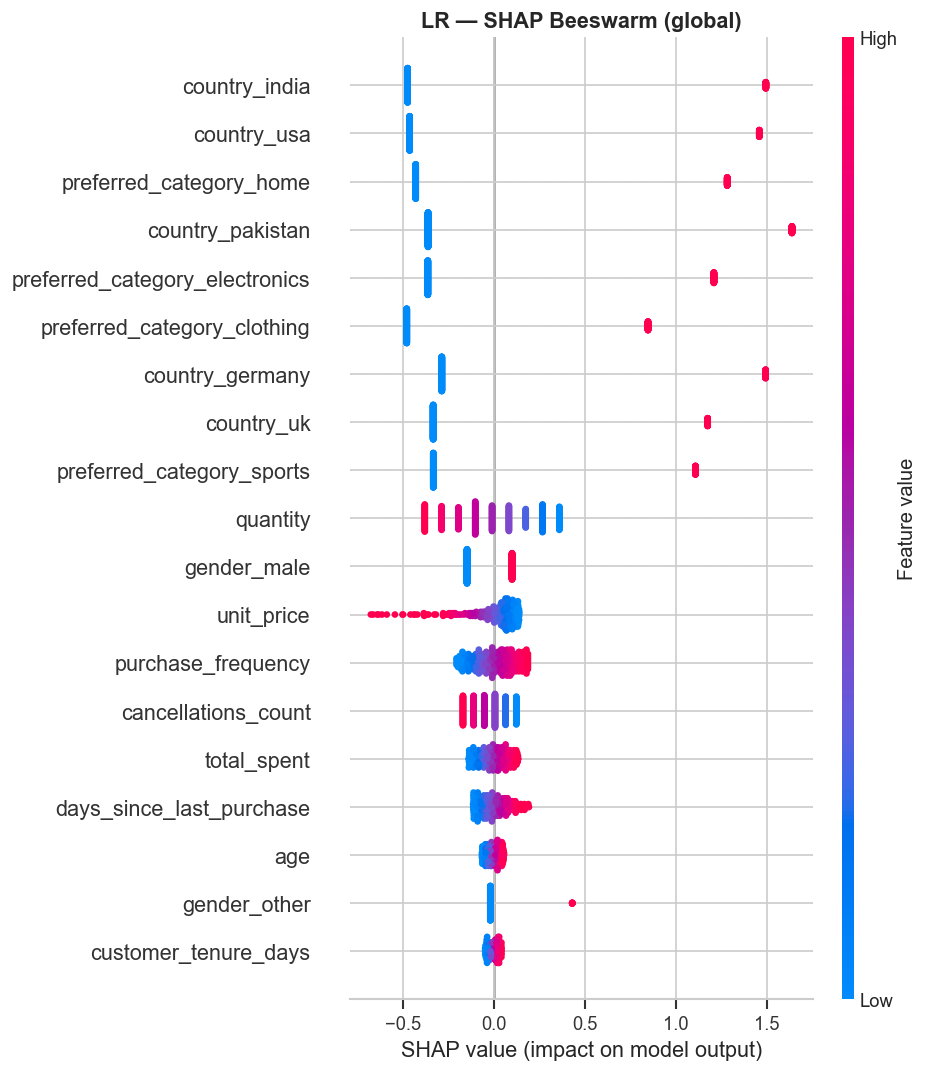

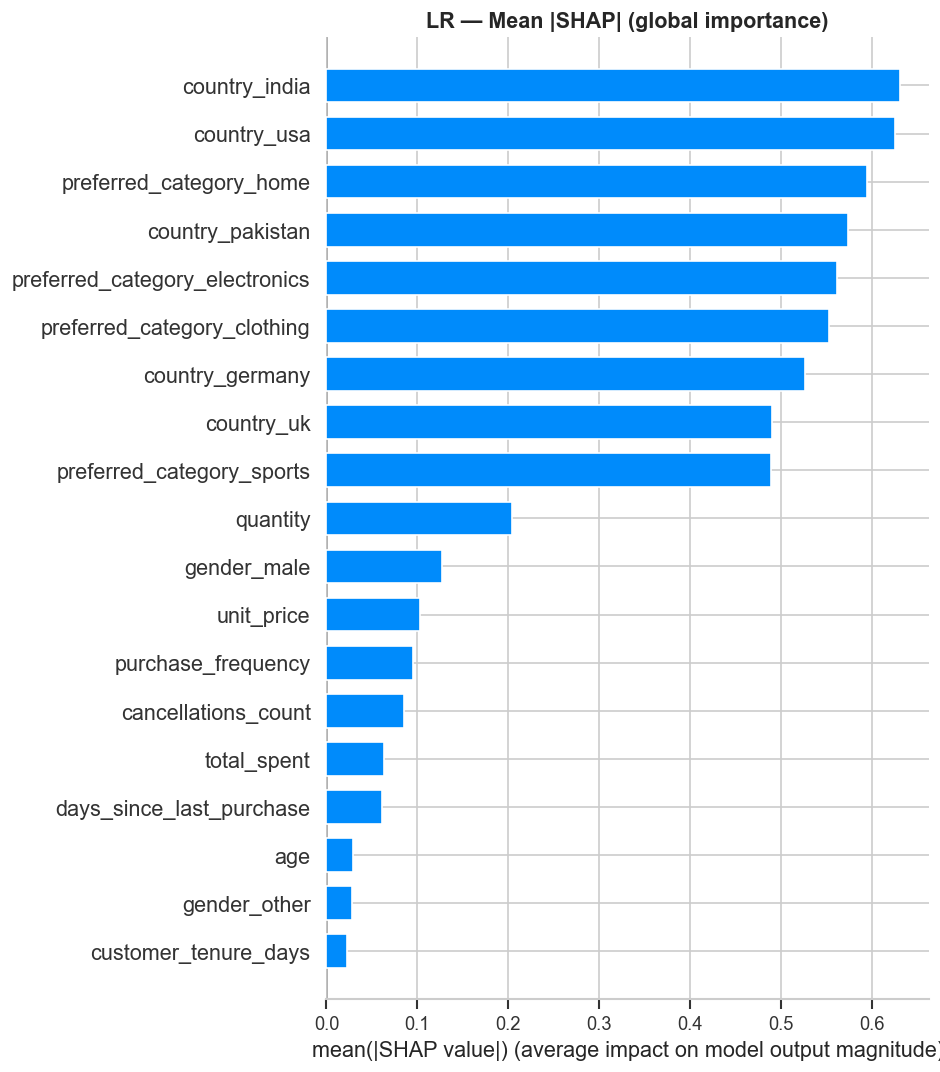

In [43]:
# LinearExplainer uses the analytical solution for linear models — exact, not approximate.
lr_explainer = shap.LinearExplainer(lr, X_train_sc, feature_perturbation="interventional")
lr_shap_vals = lr_explainer.shap_values(X_test_sc)   # shape: (n_test, n_features)

# ── Beeswarm: global importance + direction ──────────────────────────────────────
# Each dot is one customer. Colour = feature value (red=high, blue=low).
# x-axis position = SHAP value (impact on churn log-odds).
shap.summary_plot(lr_shap_vals, X_test_sc, feature_names=feature_names,
                  plot_type="dot", show=False)
plt.title("LR — SHAP Beeswarm (global)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("chart6_lr_shap_beeswarm.png", bbox_inches="tight")
plt.show()

# ── Bar: mean |SHAP| per feature ────────────────────────────────────────────────
shap.summary_plot(lr_shap_vals, X_test_sc, feature_names=feature_names,
                  plot_type="bar", show=False)
plt.title("LR — Mean |SHAP| (global importance)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("chart7_lr_shap_bar.png", bbox_inches="tight")
plt.show()


## 7 · Random Forest — MDI Importance + SHAP

### Why it is explainable
Two complementary lenses:
- **Mean Decrease in Impurity (MDI):** how much each feature reduces Gini impurity
  averaged across all trees — fast, global, but can overrate high-cardinality features.
- **SHAP TreeExplainer:** exact Shapley values that capture interaction effects
  and give per-prediction breakdowns. Directional (MDI is not).


In [44]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    class_weight="balanced_subsample", n_jobs=-1, random_state=SEED,
)
evaluate("Random Forest", rf, X_train_raw, y_train_res, X_test_raw, y_test)


  Random Forest  (1.40s)
  Accuracy   : 0.7050
  Precision  : 0.3208
  Recall     : 0.1717
  F1         : 0.2237
  ROC-AUC    : 0.5303
              precision    recall  f1-score   support

 Not Churned       0.76      0.88      0.82       301
     Churned       0.32      0.17      0.22        99

    accuracy                           0.70       400
   macro avg       0.54      0.53      0.52       400
weighted avg       0.65      0.70      0.67       400



,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 7.1 Mean Decrease in Impurity

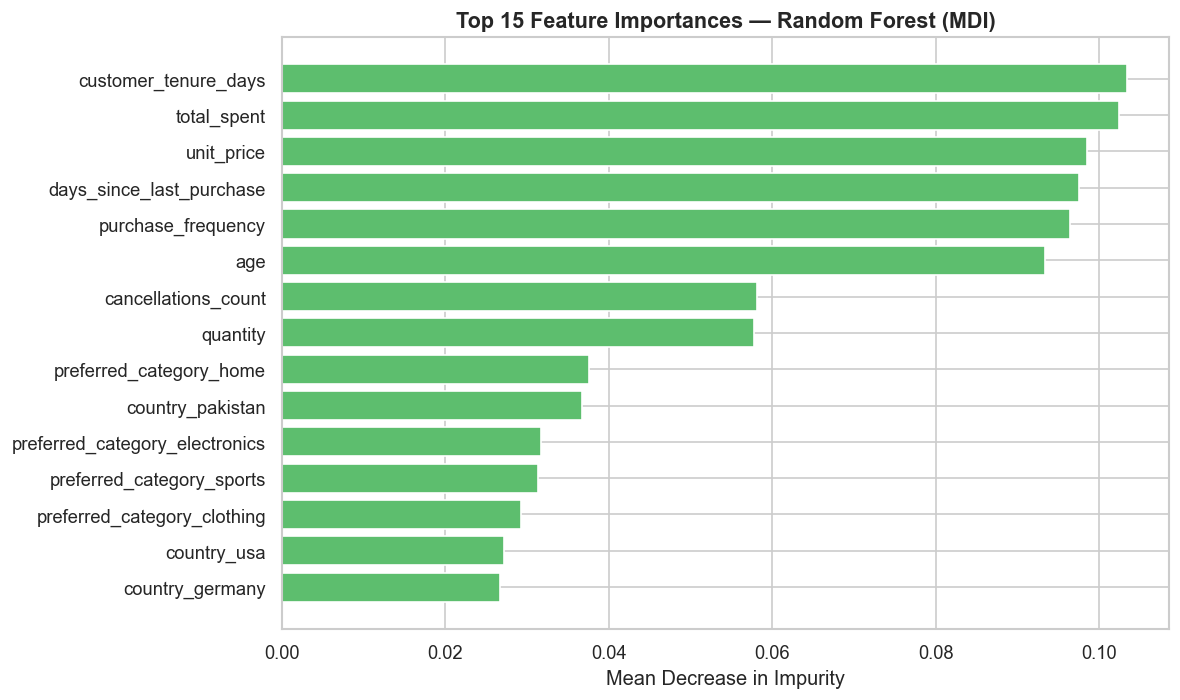

In [45]:
feat_imp = (
    pd.Series(rf.feature_importances_, index=feature_names)
    .nlargest(15)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feat_imp.index, feat_imp.values, color="#5DBE6E", edgecolor="white")
ax.set_xlabel("Mean Decrease in Impurity")
ax.set_title("Top 15 Feature Importances — Random Forest (MDI)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("chart8_rf_mdi.png", bbox_inches="tight")
plt.show()


### 7.2 RF — SHAP TreeExplainer

RF SHAP values shape (churn class): (400, 19)


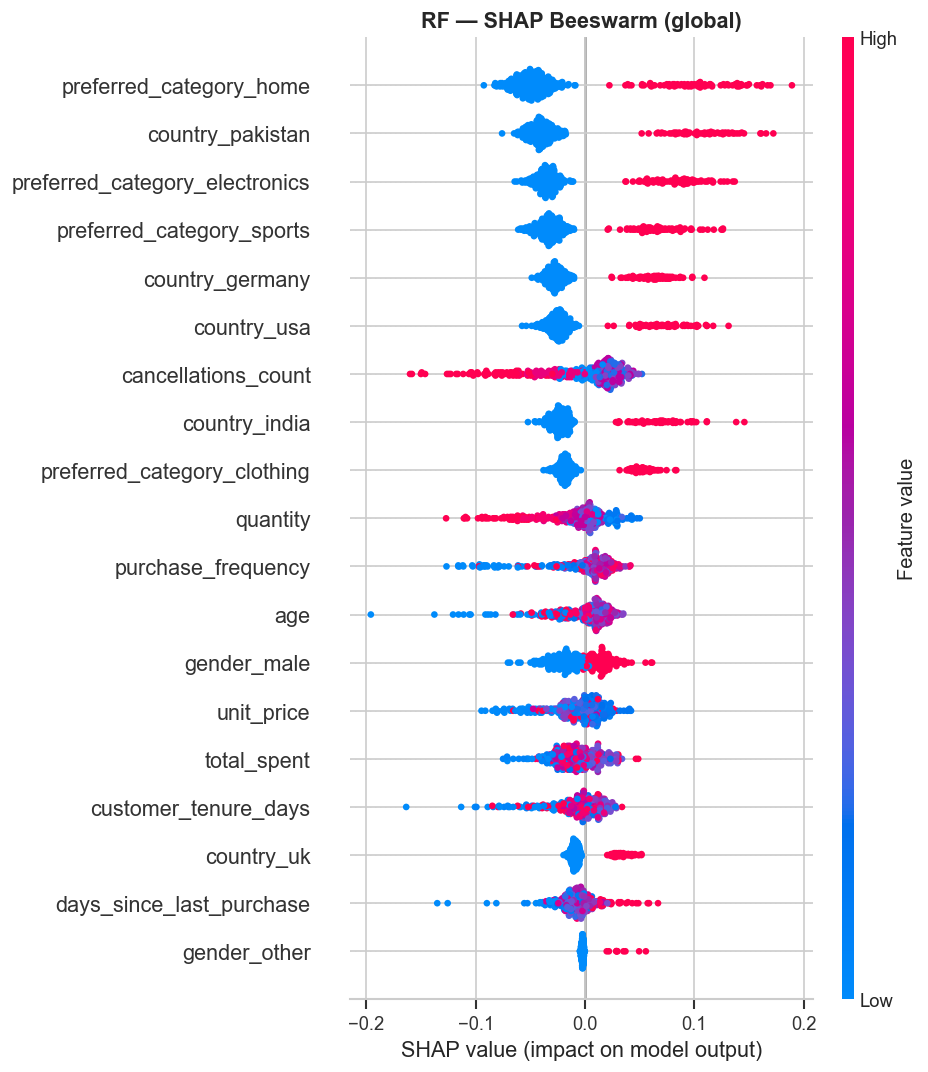

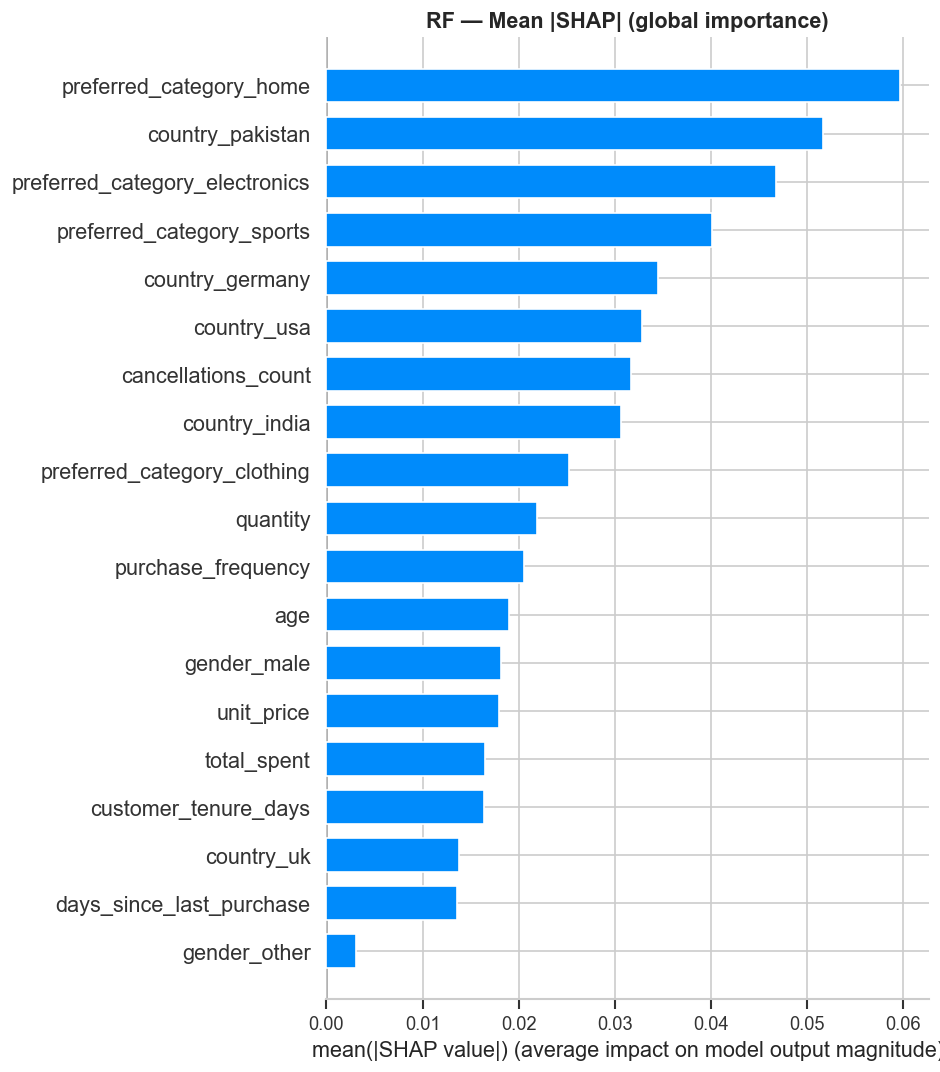

In [46]:
rf_explainer = shap.TreeExplainer(rf)
# check_additivity=False skips a slow consistency check — safe for RF
rf_shap_vals = rf_explainer.shap_values(X_test_raw, check_additivity=False)

# Newer SHAP versions return a 3D array (n_samples, n_features, n_classes);
# older versions return a list [class_0_array, class_1_array].
# Both cases: we want the class-1 (churn) slice as a 2D (n_samples, n_features) array.
if isinstance(rf_shap_vals, list):
    rf_sv_churn = rf_shap_vals[1]          # old API: list of arrays
elif rf_shap_vals.ndim == 3:
    rf_sv_churn = rf_shap_vals[:, :, 1]    # new API: 3D array, last axis = class
else:
    rf_sv_churn = rf_shap_vals              # binary output already 2D

print(f"RF SHAP values shape (churn class): {rf_sv_churn.shape}")

# ── Beeswarm ─────────────────────────────────────────────────────────────────────
shap.summary_plot(rf_sv_churn, X_test_raw, feature_names=feature_names, show=False)
plt.title("RF — SHAP Beeswarm (global)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("chart9_rf_shap_beeswarm.png", bbox_inches="tight")
plt.show()

# ── Bar ──────────────────────────────────────────────────────────────────────────
shap.summary_plot(rf_sv_churn, X_test_raw, feature_names=feature_names,
                  plot_type="bar", show=False)
plt.title("RF — Mean |SHAP| (global importance)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("chart10_rf_shap_bar.png", bbox_inches="tight")
plt.show()


### 7.3 RF — SHAP Dependence plots (top 2 features)

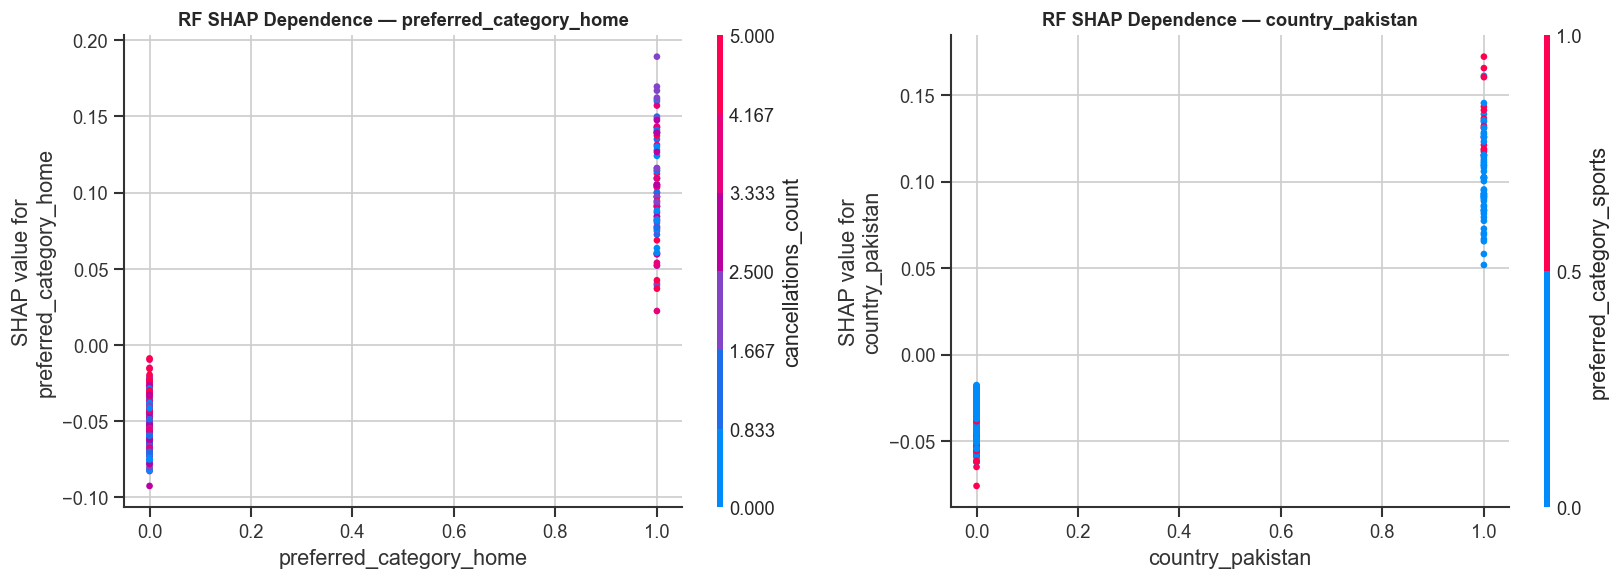

In [47]:
# Dependence plots show how a feature's SHAP value changes with its raw value.
# Colour = the feature that interacts most strongly with it.
top2_rf = (
    pd.Series(np.abs(rf_sv_churn).mean(axis=0), index=feature_names)
    .nlargest(2).index.tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat in zip(axes, top2_rf):
    shap.dependence_plot(feat, rf_sv_churn, X_test_raw,
                         feature_names=feature_names, ax=ax, show=False)
    ax.set_title(f"RF SHAP Dependence — {feat}", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("chart11_rf_shap_dependence.png", bbox_inches="tight")
plt.show()


## 8 · XGBoost — Gain Importance + SHAP

### Why it is explainable
XGBoost provides three native importance types. **Gain** is the most meaningful:
average improvement in the loss function each time a feature is used in a split.
SHAP was originally developed for gradient boosted trees — TreeExplainer is exact
and runs in polynomial time.


In [48]:
neg, pos = np.bincount(y_train_res)

xgb_clf = xgb.XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=neg / pos,
    eval_metric="logloss",
    use_label_encoder=False,
    tree_method="hist",    # GPU-ready; change device="cuda" if GPU available
    device="cpu",
    random_state=SEED,
    n_jobs=-1,
)
evaluate("XGBoost", xgb_clf, X_train_raw, y_train_res, X_test_raw, y_test)


  XGBoost  (0.36s)
  Accuracy   : 0.6950
  Precision  : 0.3380
  Recall     : 0.2424
  F1         : 0.2824
  ROC-AUC    : 0.5382
              precision    recall  f1-score   support

 Not Churned       0.77      0.84      0.81       301
     Churned       0.34      0.24      0.28        99

    accuracy                           0.69       400
   macro avg       0.56      0.54      0.54       400
weighted avg       0.66      0.69      0.68       400



,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,'cpu'
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


### 8.1 Gain-based feature importance

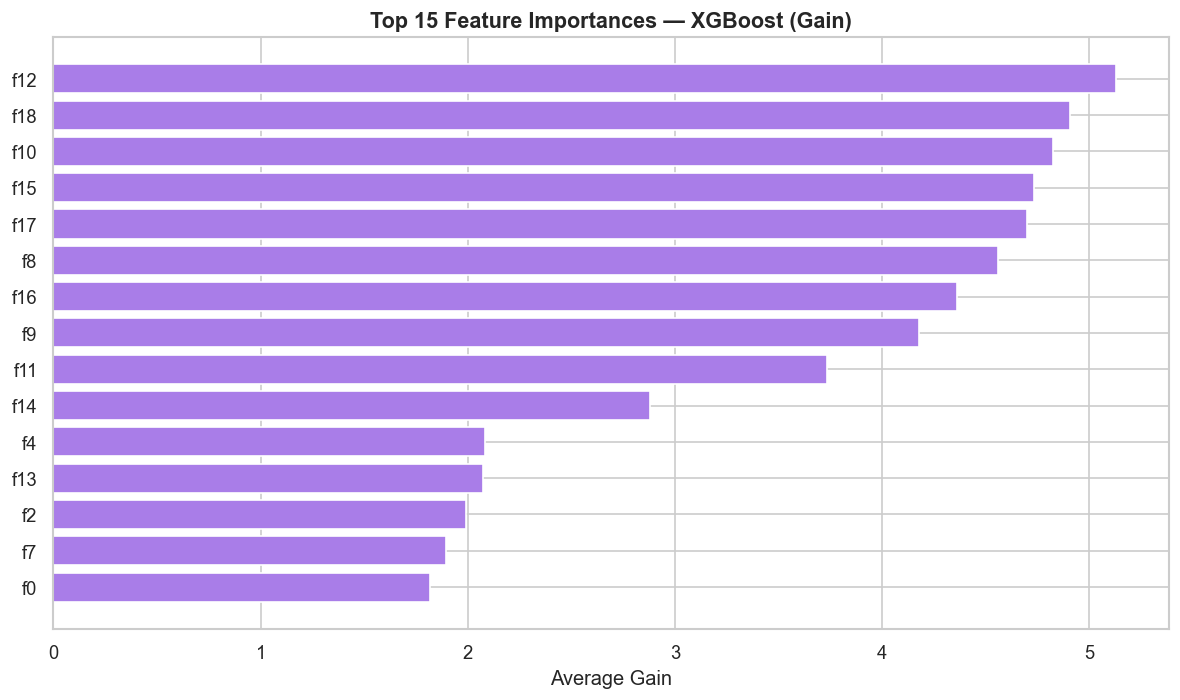

In [49]:
xgb_imp = (
    pd.Series(
        xgb_clf.get_booster().get_score(importance_type="gain"),
        name="Gain",
    )
    .sort_values(ascending=False)
    .head(15)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(xgb_imp.index, xgb_imp.values, color="#A97DE8", edgecolor="white")
ax.set_xlabel("Average Gain")
ax.set_title("Top 15 Feature Importances — XGBoost (Gain)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("chart12_xgb_gain.png", bbox_inches="tight")
plt.show()


### 8.2 XGBoost — SHAP TreeExplainer

XGBoost SHAP values shape: (400, 19)


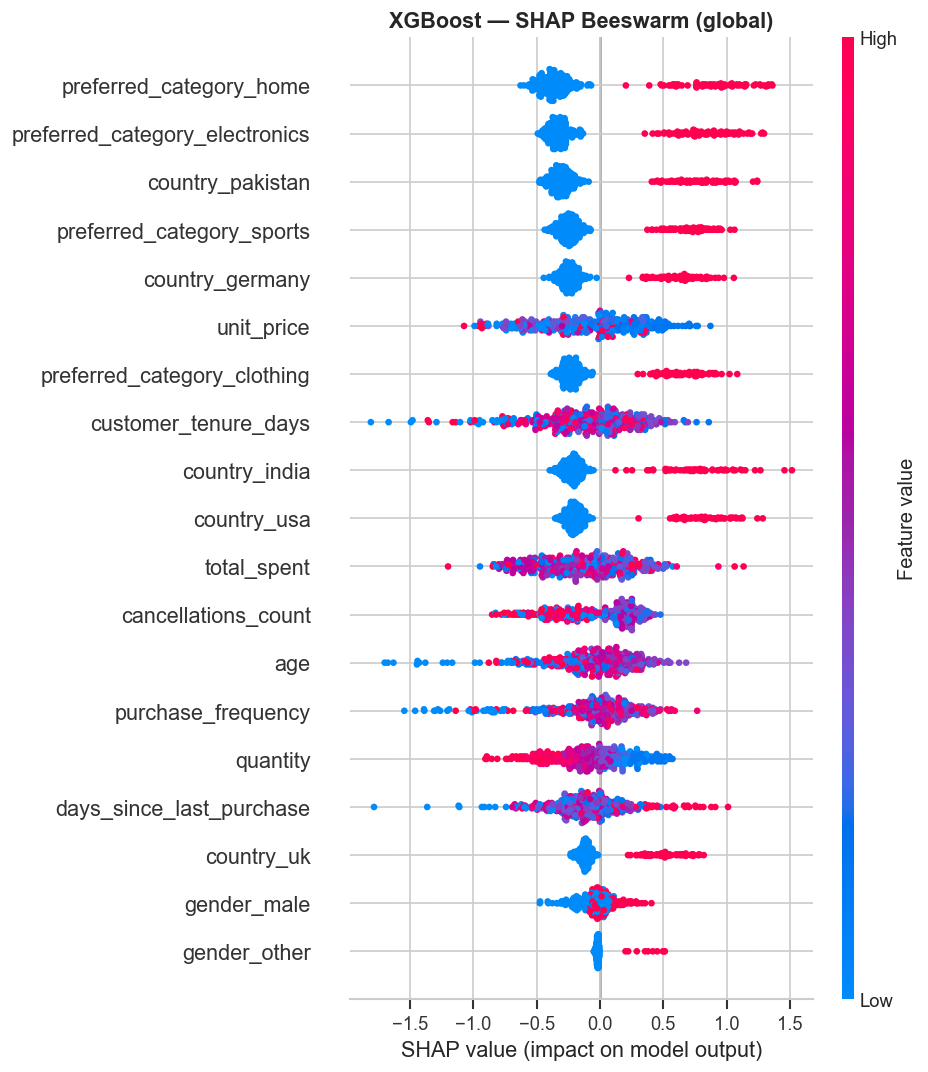

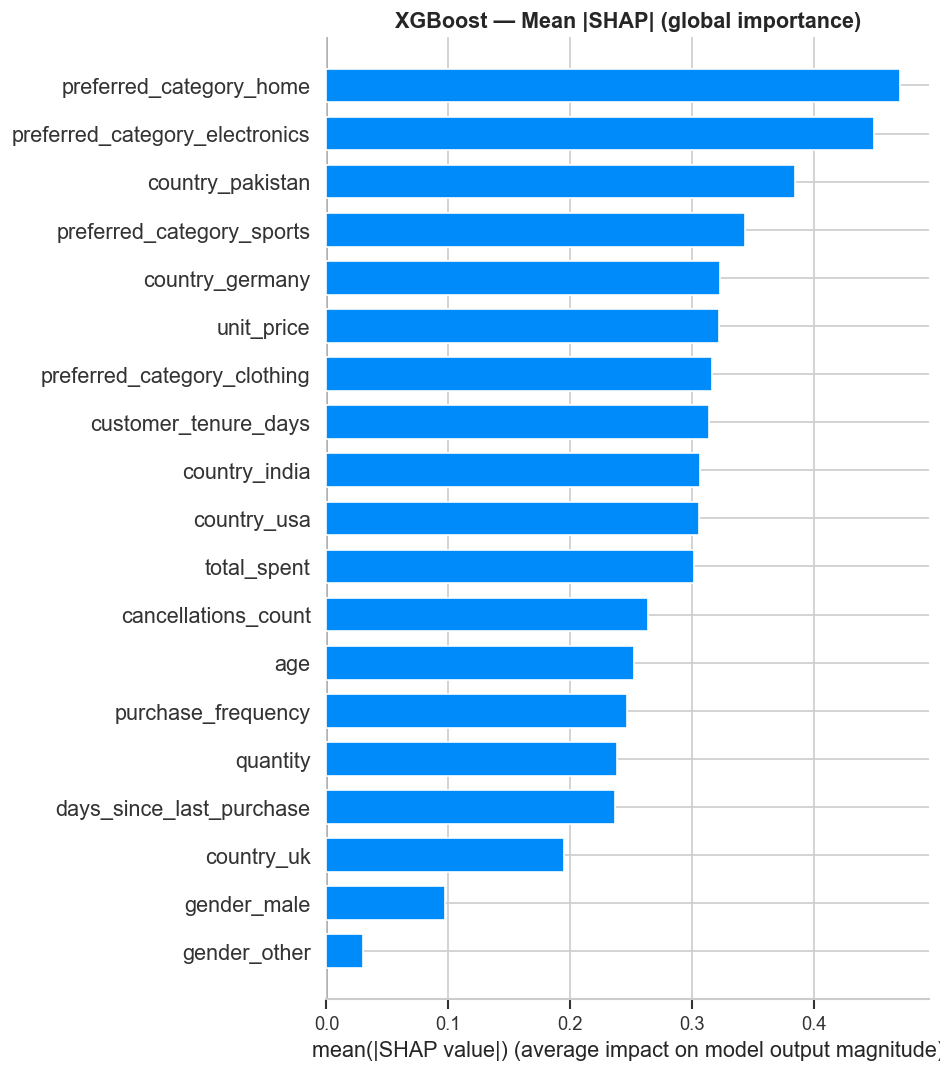

In [50]:
# Requires SHAP >= 0.51.0 for XGBoost 3.x compatibility.
# If you see an error here, run: pip install shap==0.51.0
xgb_explainer = shap.TreeExplainer(xgb_clf)
xgb_shap_vals = xgb_explainer.shap_values(X_test_raw)

print(f"XGBoost SHAP values shape: {xgb_shap_vals.shape}")

# ── Beeswarm ─────────────────────────────────────────────────────────────────────
shap.summary_plot(xgb_shap_vals, X_test_raw, feature_names=feature_names, show=False)
plt.title("XGBoost — SHAP Beeswarm (global)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("chart13_xgb_shap_beeswarm.png", bbox_inches="tight")
plt.show()

# ── Bar ──────────────────────────────────────────────────────────────────────────
shap.summary_plot(xgb_shap_vals, X_test_raw, feature_names=feature_names,
                  plot_type="bar", show=False)
plt.title("XGBoost — Mean |SHAP| (global importance)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("chart14_xgb_shap_bar.png", bbox_inches="tight")
plt.show()


### 8.3 XGBoost — SHAP Dependence plots (top 2 features)

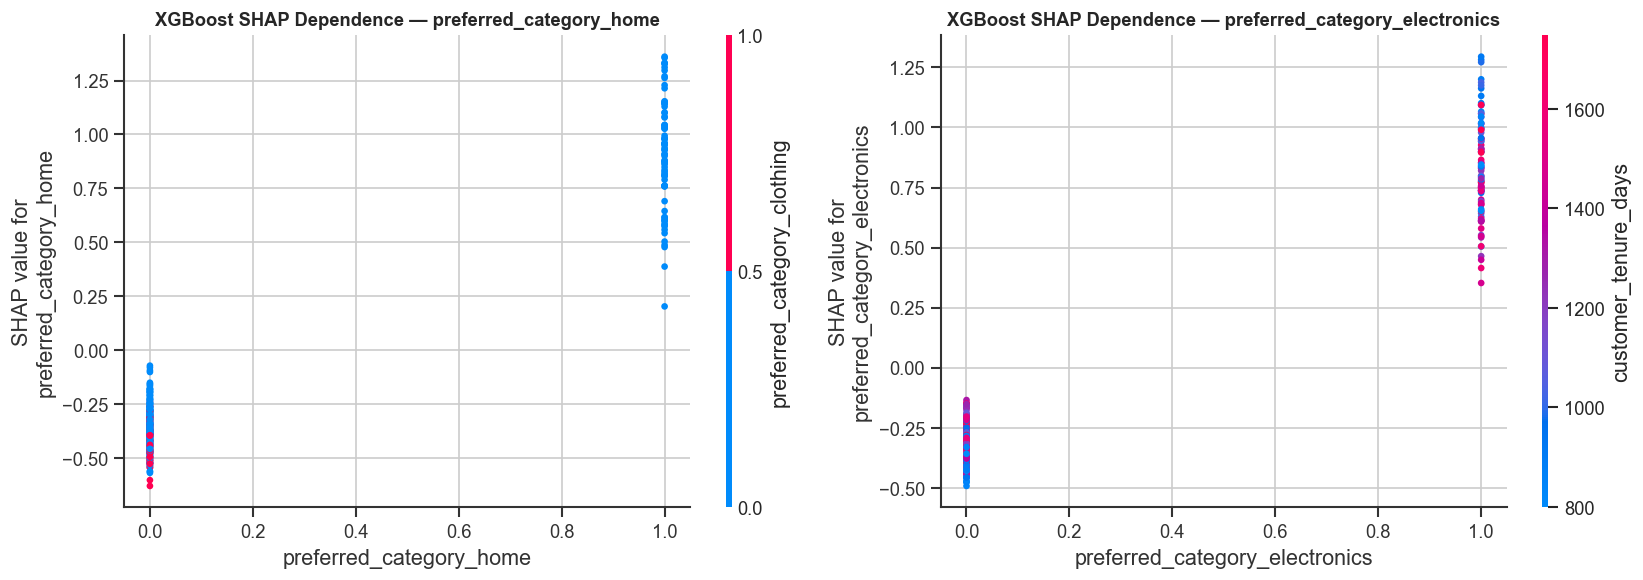

In [51]:
# Dependence plots show how a feature's SHAP value changes with its raw value.
# Colour = the feature that interacts most strongly with it.
top2_xgb = (
    pd.Series(np.abs(xgb_shap_vals).mean(axis=0), index=feature_names)
    .nlargest(2).index.tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat in zip(axes, top2_xgb):
    shap.dependence_plot(feat, xgb_shap_vals, X_test_raw,
                         feature_names=feature_names, ax=ax, show=False)
    ax.set_title(f"XGBoost SHAP Dependence — {feat}", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("chart15_xgb_shap_dependence.png", bbox_inches="tight")
plt.show()


## 9 · Cross-Model SHAP Comparison
Ranking features by mean |SHAP| across all three models.
**Agreement** across models signals genuinely important features.
**Disagreement** signals model-specific interactions worth investigating.


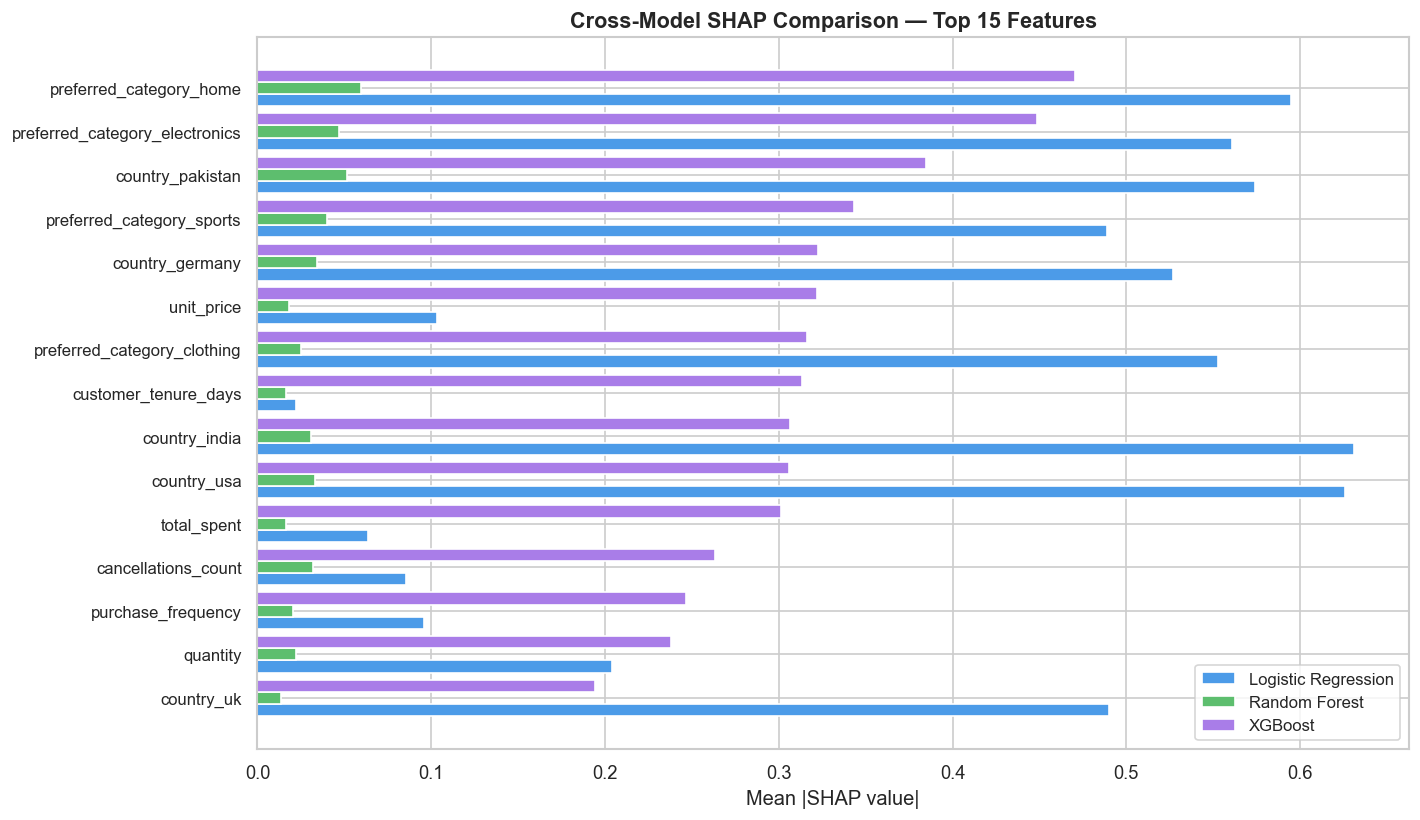


Full cross-model SHAP table (top 15):
                                Logistic Regression  Random Forest  XGBoost    Mean
preferred_category_home                      0.5949         0.0597   0.4704  0.3750
preferred_category_electronics               0.5610         0.0467   0.4488  0.3522
country_pakistan                             0.5742         0.0517   0.3846  0.3368
country_india                                0.6310         0.0307   0.3067  0.3228
country_usa                                  0.6259         0.0328   0.3058  0.3215
preferred_category_clothing                  0.5524         0.0252   0.3163  0.2980
country_germany                              0.5267         0.0344   0.3223  0.2945
preferred_category_sports                    0.4888         0.0401   0.3431  0.2907
country_uk                                   0.4902         0.0138   0.1944  0.2328
quantity                                     0.2038         0.0219   0.2381  0.1546
unit_price                           

In [52]:
shap_importance = pd.DataFrame({
    "Logistic Regression": np.abs(lr_shap_vals).mean(axis=0),
    "Random Forest":       np.abs(rf_sv_churn).mean(axis=0),
    "XGBoost":             np.abs(xgb_shap_vals).mean(axis=0),
}, index=feature_names)

shap_importance["Mean"] = shap_importance.mean(axis=1)
shap_importance = shap_importance.sort_values("Mean", ascending=False)

top15 = shap_importance.head(15).drop(columns="Mean").sort_values("XGBoost")

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(top15))
w = 0.28

ax.barh(x - w, top15["Logistic Regression"], w,
        label="Logistic Regression", color="#4C9BE8", edgecolor="white")
ax.barh(x,     top15["Random Forest"],       w,
        label="Random Forest",       color="#5DBE6E", edgecolor="white")
ax.barh(x + w, top15["XGBoost"],             w,
        label="XGBoost",             color="#A97DE8", edgecolor="white")

ax.set_yticks(x)
ax.set_yticklabels(top15.index, fontsize=10)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Cross-Model SHAP Comparison — Top 15 Features",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("chart16_cross_model_shap.png", bbox_inches="tight")
plt.show()

print("\nFull cross-model SHAP table (top 15):")
print(shap_importance.head(15).round(4).to_string())


## 10 · Individual Prediction Explainer — Waterfall & Force Plots
Waterfall plots decompose a **single prediction** into feature contributions,
starting from the base rate (model expected value) and showing how each feature
pushes the score towards the final output.

This is the most actionable output for a retention team:
> *"This customer is predicted to churn because their `cancellations_count` is
> high (+0.18) and their `purchase_frequency` is low (+0.12)..."*


In [53]:
# Pick one churned and one retained customer from the test set
churned_idx     = np.where(y_test.values == 1)[0][0]
not_churned_idx = np.where(y_test.values == 0)[0][0]

print(f"Churned customer     → test index {churned_idx}  "
      f"| predicted prob: {results['XGBoost']['y_prob'][churned_idx]:.1%}")
print(f"Retained customer    → test index {not_churned_idx}  "
      f"| predicted prob: {results['XGBoost']['y_prob'][not_churned_idx]:.1%}")


Churned customer     → test index 0  | predicted prob: 13.1%
Retained customer    → test index 1  | predicted prob: 9.3%


### 10.1 XGBoost Waterfall plots

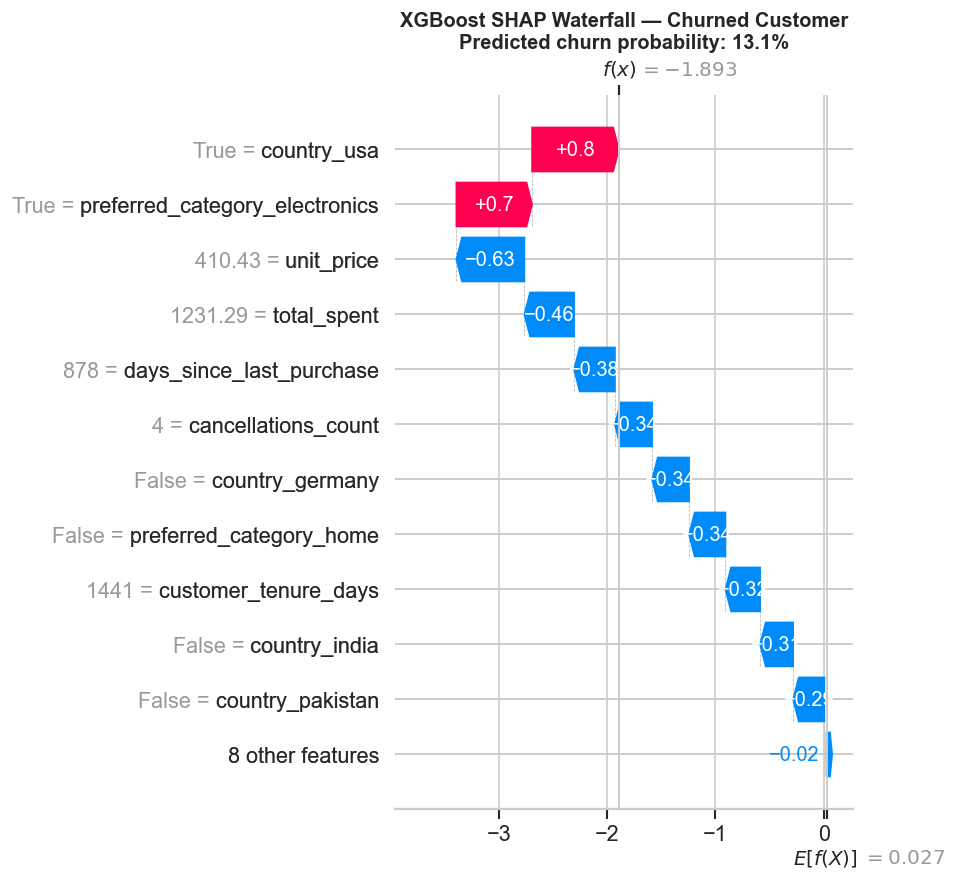

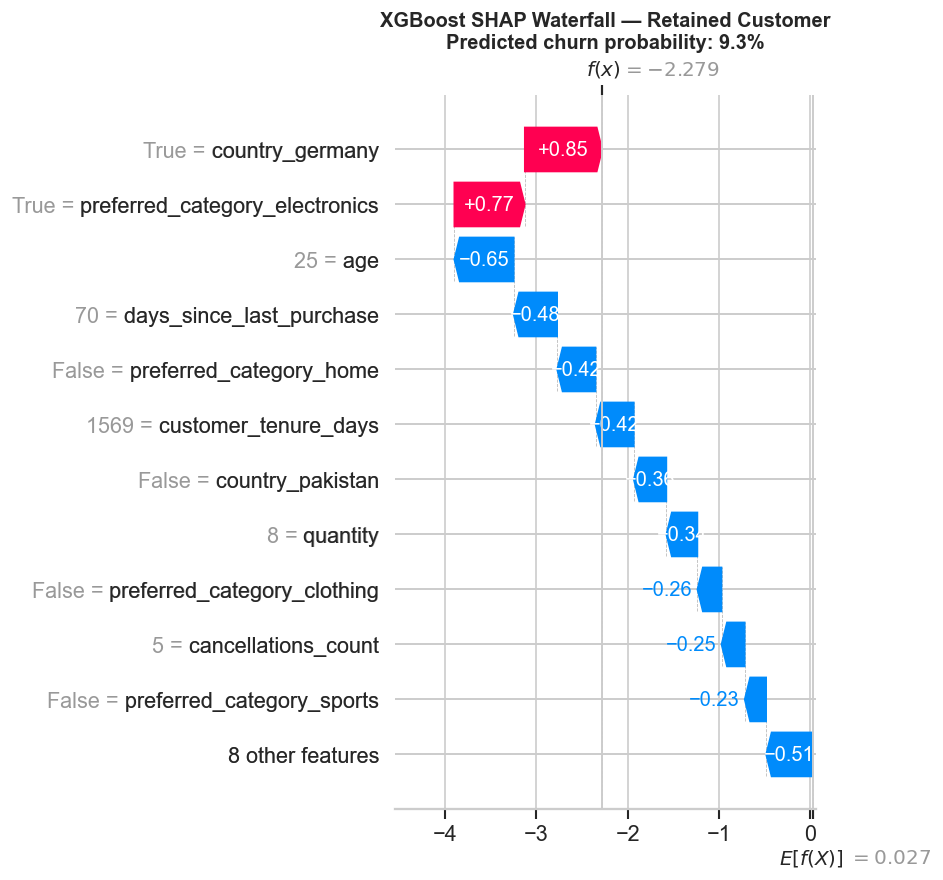

In [54]:
ev = xgb_explainer.expected_value
if isinstance(ev, np.ndarray):
    ev = float(ev[1])  # class 1 (churn)

xgb_exp = shap.Explanation(
    values        = xgb_shap_vals,
    base_values   = np.full(len(xgb_shap_vals), ev),
    data          = X_test_raw,
    feature_names = feature_names,
)

for idx, label in [
    (churned_idx,     "Churned Customer"),
    (not_churned_idx, "Retained Customer"),
]:
    shap.waterfall_plot(xgb_exp[idx], max_display=12, show=False)
    plt.title(
        f"XGBoost SHAP Waterfall — {label}\n"
        f"Predicted churn probability: {results['XGBoost']['y_prob'][idx]:.1%}",
        fontsize=12, fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig(f"chart17_waterfall_{label.split()[0].lower()}.png", bbox_inches="tight")
    plt.show()


### 10.2 Force plots (horizontal alternative)

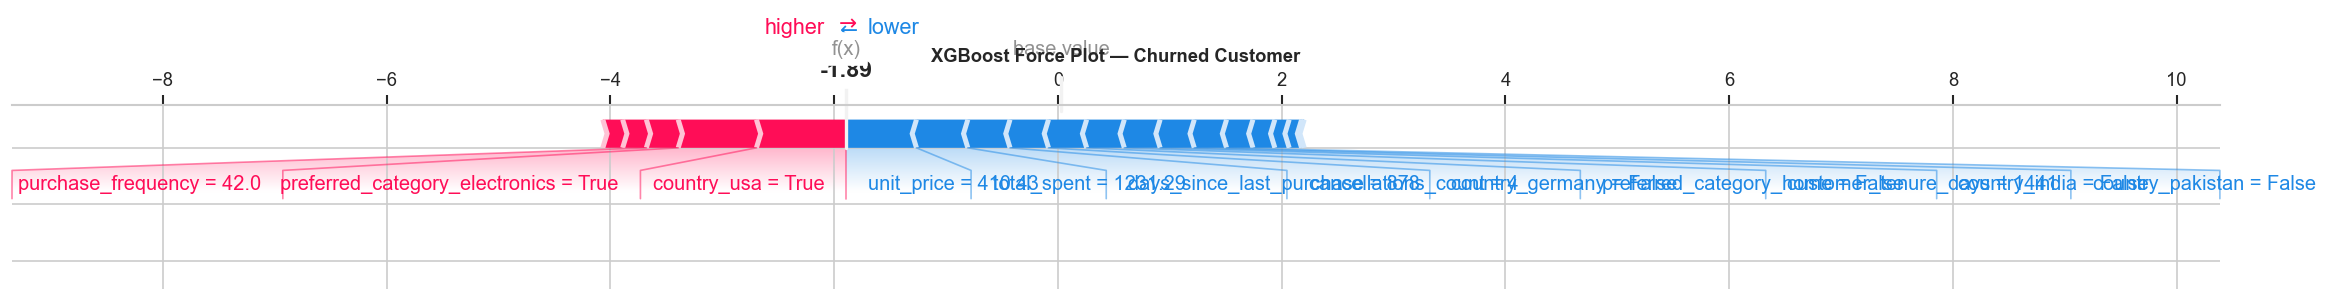

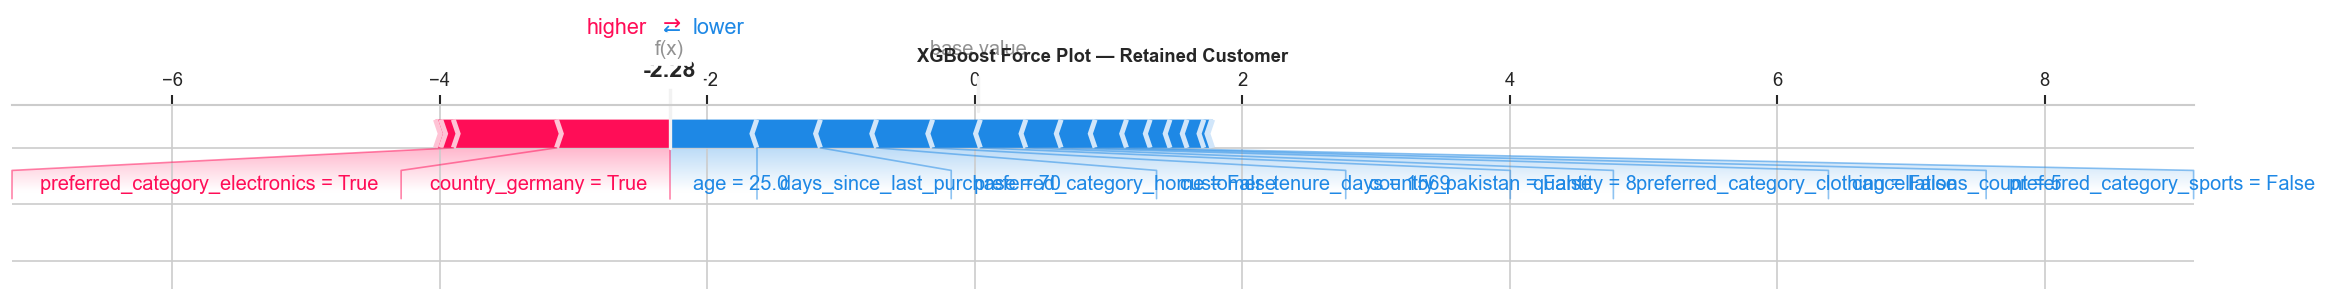

In [55]:
# Force plots using XGBoost SHAP (horizontal alternative to waterfall)
ev = xgb_explainer.expected_value
if isinstance(ev, np.ndarray):
    ev = float(ev[1])

shap.initjs()

for idx, label in [
    (churned_idx,     "Churned Customer"),
    (not_churned_idx, "Retained Customer"),
]:
    shap.force_plot(
        ev,
        xgb_shap_vals[idx],
        X_test_raw[idx],
        feature_names=feature_names,
        matplotlib=True,
        show=False,
    )
    plt.title(f"XGBoost Force Plot — {label}", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"chart18_force_{label.split()[0].lower()}.png", bbox_inches="tight")
    plt.show()


## 11 · Results Summary & Recommendations

In [56]:
rows = []
for name, res in results.items():
    m = res["metrics"]
    rows.append({"Model": name, **{k: round(v, 4) for k, v in m.items()}})

summary_df = (
    pd.DataFrame(rows)
    .sort_values("ROC_AUC", ascending=False)
    .reset_index(drop=True)
)
print(summary_df.to_string(index=False))


              Model  Accuracy  Precision  Recall     F1  ROC_AUC  Train_sec
            XGBoost    0.6950     0.3380  0.2424 0.2824   0.5382       0.36
Logistic Regression    0.6575     0.3021  0.2929 0.2974   0.5310       0.01
      Random Forest    0.7050     0.3208  0.1717 0.2237   0.5303       1.40


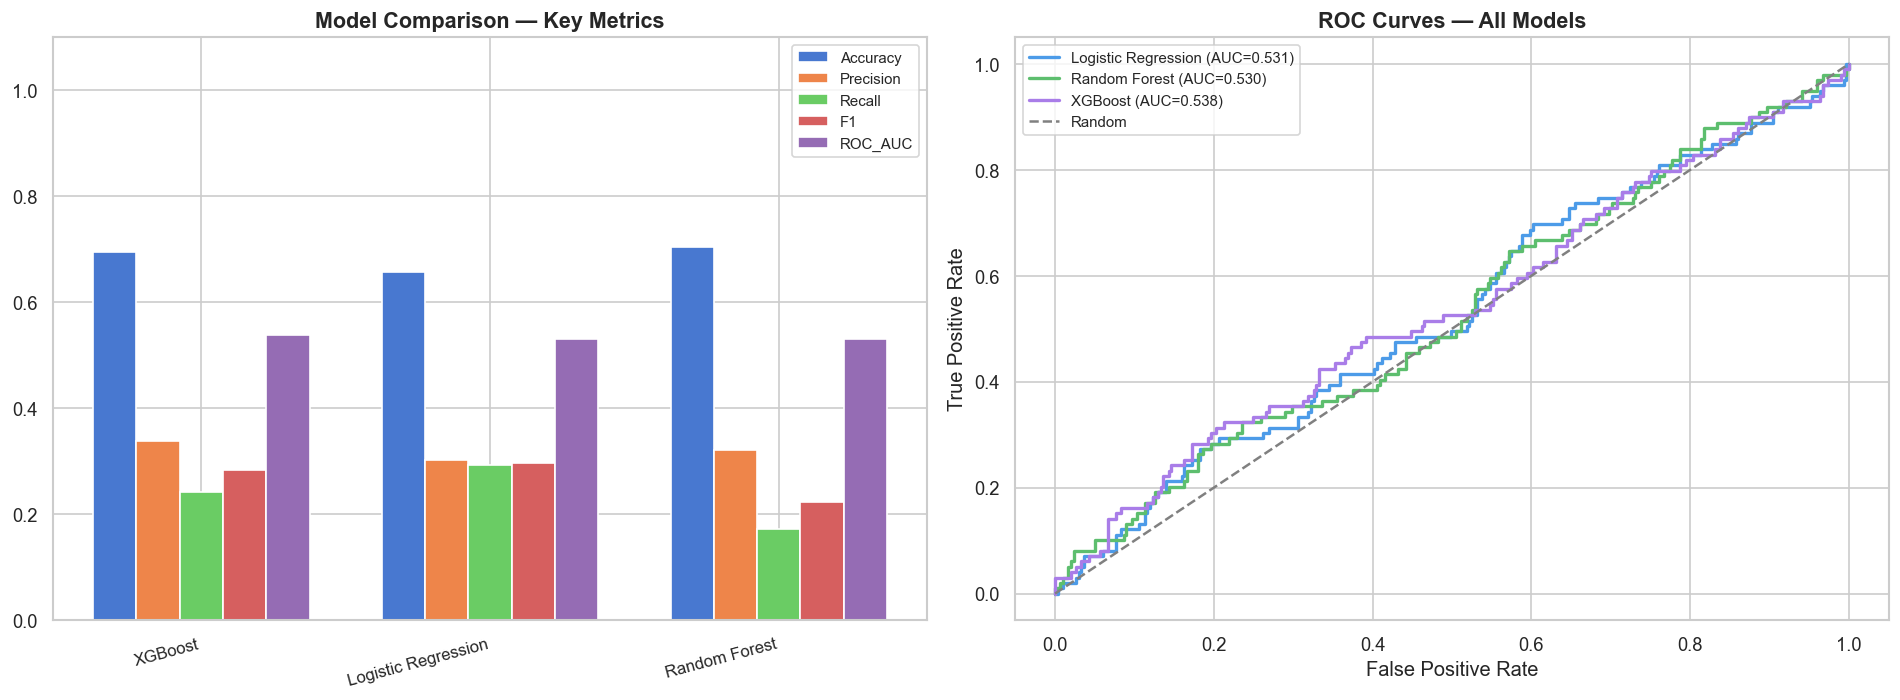

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = ["#4C9BE8", "#5DBE6E", "#A97DE8"]

# ── Metric bars ──────────────────────────────────────────────────────────────────
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
x = np.arange(len(summary_df))
width = 0.15
for i, metric in enumerate(metrics_to_plot):
    axes[0].bar(x + i * width, summary_df[metric], width, label=metric)
axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(summary_df["Model"], rotation=15, ha="right", fontsize=10)
axes[0].set_ylim(0, 1.1)
axes[0].set_title("Model Comparison — Key Metrics", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=9)

# ── ROC curves ───────────────────────────────────────────────────────────────────
for i, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    auc = res["metrics"]["ROC_AUC"]
    axes[1].plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc:.3f})", color=palette[i])
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="Random")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curves — All Models", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("chart19_model_comparison.png", bbox_inches="tight")
plt.show()


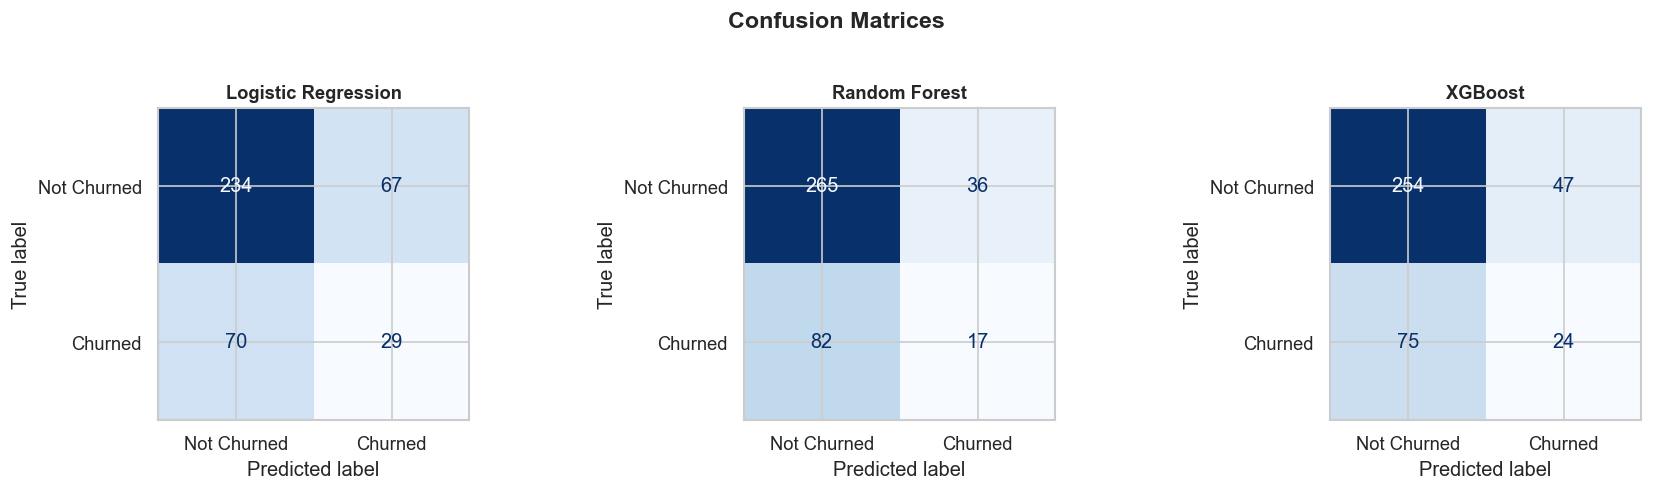

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=["Not Churned", "Churned"]).plot(
        ax=ax, cmap="Blues", colorbar=False,
    )
    ax.set_title(name, fontsize=11, fontweight="bold")
plt.suptitle("Confusion Matrices", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("chart20_confusion_matrices.png", bbox_inches="tight")
plt.show()


In [60]:
best = summary_df.iloc[0]
print(f"\n{'='*58}")
print(f"  Best model by ROC-AUC : {best['Model']}")
print(f"  ROC-AUC               : {best['ROC_AUC']:.4f}")
print(f"{'='*58}")

print("""
► Explainability summary:

  Logistic Regression
    · Coefficients give direct log-odds — simplest to audit.
    · Odds ratios (exp(coef)) are presentation-ready for executives.
    · SHAP LinearExplainer confirms coefficients with per-customer detail.

  Random Forest
    · MDI importance shows which features drive splits globally.
    · SHAP adds directionality that MDI alone cannot provide.
    · Dependence plots reveal non-linear patterns and interactions.

  XGBoost
    · Gain importance is more reliable than simple split counts.
    · SHAP is exact for boosted trees — no sampling approximation.
    · Waterfall & force plots give actionable per-customer reasoning
      that a retention team can act on directly.

► Recommended for production:
    XGBoost + SHAP waterfall plots  →  retention / CRM team
    Logistic Regression odds ratios →  executive / board reporting
""")

summary_df.to_csv("explainable_models_summary.csv", index=False)
print("Saved: explainable_models_summary.csv")



  Best model by ROC-AUC : XGBoost
  ROC-AUC               : 0.5382

► Explainability summary:

  Logistic Regression
    · Coefficients give direct log-odds — simplest to audit.
    · Odds ratios (exp(coef)) are presentation-ready for executives.
    · SHAP LinearExplainer confirms coefficients with per-customer detail.

  Random Forest
    · MDI importance shows which features drive splits globally.
    · SHAP adds directionality that MDI alone cannot provide.
    · Dependence plots reveal non-linear patterns and interactions.

  XGBoost
    · Gain importance is more reliable than simple split counts.
    · SHAP is exact for boosted trees — no sampling approximation.
    · Waterfall & force plots give actionable per-customer reasoning
      that a retention team can act on directly.

► Recommended for production:
    XGBoost + SHAP waterfall plots  →  retention / CRM team
    Logistic Regression odds ratios →  executive / board reporting

Saved: explainable_models_summary.csv
